# LLM Time-Series Anomaly Detection: SFT Pipeline

**参考链接**
- [AnomLLM](https://github.com/Rose-STL-Lab/AnomLLM)
- [Unsloth Vision SFT](https://docs.unsloth.ai/basics/vision-fine-tuning)
- [Unsloth Qwen3-VL](https://docs.unsloth.ai/models/qwen3-vl)
- [vLLM Server](https://docs.vllm.ai/en/latest/serving/openai_compatible_server.html)

**数据**：AnomLLM 合成数据集，4 个子集（flat-trend / range / point / freq），每个 400 条，长度 1000 单通道时序 + 预渲染 PNG

**流程**：Phase 0-1 环境 → Phase 2-4 Baseline → Phase 5-7 SFT 数据 → Phase 8 训练 → Phase 9 评估 → Phase 10 可选 GRPO

**标记说明**
- 🔑 **需要你操作** — 需要填入密钥等信息
- ⏸ **需要你判断** — 查看可视化结果，确认无误后继续
- 📊 可视化 — 过程性检查图表

---
## 阶段 0. 初始化环境

### Cell 0.1 — 挂载 Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Cell 0.2 — 定义运行目录

In [2]:
from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")

RT_CODE    = RUNTIME / "code"
RT_SFT     = RUNTIME / "sft"
RT_CKPT    = RUNTIME / "checkpoints"
RT_RESULTS = RUNTIME / "results"

DRV_PACK   = DRIVE_ROOT / "packs"
DRV_SFT    = DRIVE_ROOT / "sft"
DRV_CKPT   = DRIVE_ROOT / "checkpoints"
DRV_RESULTS= DRIVE_ROOT / "results"

for p in [RUNTIME, RT_CODE, RT_SFT, RT_CKPT, RT_RESULTS,
          DRV_PACK, DRV_SFT, DRV_CKPT, DRV_RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

ANOMLLM = RT_CODE / "AnomLLM"

### Cell 0.3 — 安装依赖

In [3]:
!pip install -U pip -q
!pip install "unsloth[colab-new]" -q
!pip install vllm openai accelerate bitsandbytes scikit-learn pandas pyyaml datasets matplotlib pillow trl loguru google-generativeai requests -q
!pip install "git+https://github.com/ahstat/affiliation-metrics-py.git" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
google-adk 1.28.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0 which is incompatible.
google-adk 1.28.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


---
## 阶段 1. 获取 AnomLLM 代码和数据

### Cell 1.1 — 克隆仓库

In [4]:
%%bash
if [ ! -d /content/tsad_runtime/code/AnomLLM ]; then
  git clone https://github.com/Rose-STL-Lab/AnomLLM.git /content/tsad_runtime/code/AnomLLM
fi

Cloning into '/content/tsad_runtime/code/AnomLLM'...


In [5]:
import os
os.environ["PYTHONPATH"] = "/content/tsad_runtime/code/AnomLLM/src"

### Cell 1.2 — 下载数据

In [6]:
%%bash
# 优先从 Drive 恢复
if [ -f /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar ]; then
  tar -xf /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar \
      -C /content/tsad_runtime/code/AnomLLM
else
  # 方案 A：从 S3 下载预生成数据
  pip install s5cmd -q
  cd /content/tsad_runtime/code/AnomLLM
  s5cmd --no-sign-request --endpoint-url https://s3-west.nrp-nautilus.io \
      cp "s3://anomllm/data/*" data/

  # 方案 B：本地生成（若 S3 不可用，取消下面注释）
  # cd /content/tsad_runtime/code/AnomLLM && bash synthesize.sh

  # 打包备份到 Drive
  tar -cf /content/drive/MyDrive/tsad_anomaly/packs/anomllm_data.tar \
      -C /content/tsad_runtime/code/AnomLLM data
fi

### Cell 1.3 — 确认数据结构

In [7]:
import pickle, os

for subset in ["point", "range", "freq", "flat-trend"]:
    pkl = f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl"
    with open(pkl, "rb") as f:
        d = pickle.load(f)
    print(subset, "series:", len(d["series"]), d["series"][0].shape,
          "| has_figs:", os.path.isdir(pkl.replace("data.pkl","figs")))

point series: 400 (1000, 1) | has_figs: True
range series: 400 (1000, 1) | has_figs: True
freq series: 400 (1000, 1) | has_figs: True
flat-trend series: 400 (1000, 1) | has_figs: True


### Cell 1.4 — 固定数据子集

In [8]:
DATASETS = ["flat-trend", "range", "point", "freq"]

### 📊 可视化：数据集概览

In [ ]:
import pickle, matplotlib.pyplot as plt

subsets = ["flat-trend", "range", "point", "freq"]
normal_counts, anom_counts = [], []

for subset in subsets:
    with open(f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl", "rb") as f:
        d = pickle.load(f)
    n_anom = sum(1 for a in d["anom"] if len(a[0]) > 0)
    anom_counts.append(n_anom)
    normal_counts.append(len(d["anom"]) - n_anom)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(subsets))
ax.bar(x, normal_counts, label="Normal", color="#66BB6A", edgecolor="black")
ax.bar(x, anom_counts, bottom=normal_counts, label="Anomaly", color="#EF5350", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(subsets)
ax.set_ylabel("样本数")
ax.set_title("各子集样本数与异常/正常占比")
ax.legend()
fig.tight_layout()
plt.show()

---
## ⏸ 检查点 A：环境 + 数据就绪

检查：GPU / VRAM / BF16、四个子集各 400 条、`has_figs: True`、上方柱状图合理

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("Free VRAM:", round(torch.cuda.mem_get_info()[0] / 1e9, 1), "GB")
print("BF16:", torch.cuda.is_bf16_supported())

import unsloth
print("unsloth OK")

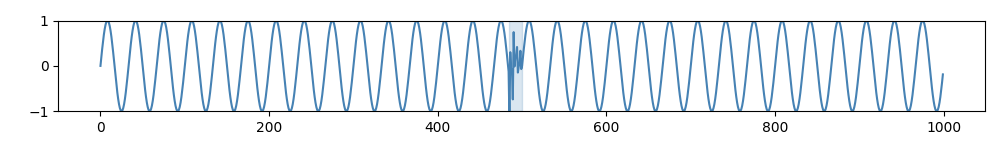

In [10]:
from IPython.display import Image
Image("/content/tsad_runtime/code/AnomLLM/data/synthetic/point/eval/figs/001.png")

---
## 阶段 2. VLM Baseline

### Cell 2.1 — 启动本地 Qwen3-VL endpoint（后台运行）

**⏸ 需要你判断**：运行后等待 vLLM 加载完成，运行下方 health check cell 确认返回 200 后再继续。

In [11]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

!nohup python -m vllm.entrypoints.openai.api_server \
  --model Qwen/Qwen3-VL-8B-Instruct \
  --served-model-name qwen-local \
  --host 127.0.0.1 --port 8000 \
  --max-model-len 8192 \
  --gpu-memory-utilization 0.95 \
  > /tmp/vllm.log 2>&1 &

^C


### Cell 2.2 — 写 credentials.yml

In [12]:
creds = """\
qwen-local:
  api_key: dummy
  base_url: "http://127.0.0.1:8000/v1"
"""
(ANOMLLM / "credentials.yml").write_text(creds)

68

In [26]:
!tail -n 20 /tmp/vllm.log

(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/models, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /ping, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /ping, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /invocations, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/chat/completions, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/chat/completions/batch, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=28722) INFO 04-04 06:28:37 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=2

In [27]:
!curl -i http://127.0.0.1:8000/health

HTTP/1.1 200 OK
date: Sat, 04 Apr 2026 07:01:08 GMT
server: uvicorn
content-length: 0



### Cell 2.3 — 跑 VLM baseline 全量

运行后检查下方可视化 cell 确认输出格式正确。

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/online_api.py --data "$datum" --model qwen-local --variant 0shot-vision
done

### 📊 可视化：VLM Baseline 输出检查

In [ ]:
from pathlib import Path
import json

root = Path("/content/tsad_runtime/code/AnomLLM/results/synthetic")
subsets = ["flat-trend", "range", "point", "freq"]
expected_ids = {f"{i:05d}" for i in range(1, 401)}

def parse_output_local(output: str):
    trimmed = output[output.index('['):output.rindex(']') + 1]
    parsed = json.loads(trimmed)
    if not isinstance(parsed, list):
        raise ValueError("response is not a list")
    for item in parsed:
        if not isinstance(item, dict):
            raise ValueError("non-dict item")
        if "start" not in item or "end" not in item:
            raise ValueError("missing start/end")
    return parsed

for subset in subsets:
    fn = root / subset / "qwen-local" / "0shot-vision.jsonl"
    assert fn.exists(), f"missing file: {fn}"

    with open(fn) as f:
        lines = f.readlines()

    seen = set()
    bad = []

    for line_no, line in enumerate(lines, 1):
        try:
            obj = json.loads(line)
            assert {"custom_id", "request", "response"} <= obj.keys()
            seen.add(obj["custom_id"].split("_")[-1])
            parse_output_local(obj["response"])
        except Exception as e:
            bad.append((line_no, str(e)))

    missing = sorted(expected_ids - seen)

    print(f"\n[{subset}]")
    print("lines:", len(lines))
    print("missing_ids:", len(missing))
    print("bad_rows:", len(bad))

    if missing:
        print("missing sample:", missing[:10])
    if bad:
        print("bad sample:", bad[:3])

print("\n检查完成")


[flat-trend]
lines: 400
missing_ids: 0
bad_rows: 0

[range]
lines: 400
missing_ids: 0
bad_rows: 0

[point]
lines: 400
missing_ids: 0
bad_rows: 0

[freq]
lines: 400
missing_ids: 0
bad_rows: 0

检查完成


---
## 阶段 3. 统计 Baseline

### Cell 3.1 — Isolation Forest

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/baselines/isoforest.py --data "$datum" --model isolation-forest
done

---
## 阶段 4. 汇总 Baseline 对比

### Cell 4.1 — result_agg.py 生成指标

In [ ]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
mkdir -p results/agg

python src/result_agg.py --data_name flat-trend --label_name flat-trend-exp \
    --table_caption "Trend anomalies (flat)"
python src/result_agg.py --data_name range --label_name range-exp \
    --table_caption "Out-of-range anomalies"
python src/result_agg.py --data_name point --label_name point-exp \
    --table_caption "Point anomalies"
python src/result_agg.py --data_name freq --label_name freq-exp \
    --table_caption "Frequency anomalies"

### Cell 4.2 — 合并成对比 CSV

In [ ]:
import pickle, pandas as pd

frames = []
for datum in ["flat-trend", "range", "point", "freq"]:
    with open(f"/content/tsad_runtime/code/AnomLLM/results/agg/{datum}.pkl", "rb") as f:
        df = pickle.load(f)
    df.insert(0, "dataset", datum)
    frames.append(df)

baseline_df = pd.concat(frames)
baseline_df.to_csv("/content/tsad_runtime/results/baseline_compare.csv")
print(baseline_df.to_string())

                                  dataset  precision    recall        f1  affi precision  affi recall   affi f1
model            variant                                                                                       
isolation-forest 0shot         flat-trend   0.065295  0.203268  0.092815        0.223412     0.422302  0.292167
qwen-local       0shot-vision  flat-trend   0.575000  0.575000  0.575000        0.575000     0.575000  0.575000
isolation-forest 0shot              range   0.158695  0.697488  0.236693        0.423843     0.697500  0.524988
qwen-local       0shot-vision       range   0.459190  0.633757  0.493413        0.914767     0.906340  0.905018
isolation-forest 0shot              point   0.033785  0.704710  0.061788        0.356710     0.707500  0.474320
qwen-local       0shot-vision       point   0.516058  0.641005  0.545357        0.902663     0.888222  0.889508
isolation-forest 0shot               freq   0.034058  0.900000  0.064442        0.452705     0.900000  0

---
## ⏸ 检查点 B：Baseline 完成

检查：所有 jsonl 均 400 行、各子集 F1 非零（期望 0.2~0.7）

In [ ]:
%%bash
echo "=== VLM baseline ==="
wc -l /content/tsad_runtime/code/AnomLLM/results/synthetic/*/qwen-local/0shot-vision.jsonl
echo "=== Isolation Forest ==="
wc -l /content/tsad_runtime/code/AnomLLM/results/synthetic/*/isolation-forest/0shot.jsonl

=== VLM baseline ===
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/flat-trend/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/freq/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/point/qwen-local/0shot-vision.jsonl
     400 /content/tsad_runtime/code/AnomLLM/results/synthetic/range/qwen-local/0shot-vision.jsonl
    1600 total
=== Isolation Forest ===
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/flat-trend/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/freq/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/point/isolation-forest/0shot.jsonl
    400 /content/tsad_runtime/code/AnomLLM/results/synthetic/range/isolation-forest/0shot.jsonl
   1600 total


In [ ]:
import pandas as pd
print(pd.read_csv("/content/tsad_runtime/results/baseline_compare.csv").to_string())

              model       variant     dataset  precision    recall        f1  affi precision  affi recall   affi f1
0  isolation-forest         0shot  flat-trend   0.065295  0.203267  0.092815        0.223412     0.422302  0.292167
1        qwen-local  0shot-vision  flat-trend   0.575000  0.575000  0.575000        0.575000     0.575000  0.575000
2  isolation-forest         0shot       range   0.158695  0.697488  0.236693        0.423843     0.697500  0.524988
3        qwen-local  0shot-vision       range   0.459190  0.633757  0.493412        0.914767     0.906340  0.905018
4  isolation-forest         0shot       point   0.033785  0.704710  0.061788        0.356710     0.707500  0.474320
5        qwen-local  0shot-vision       point   0.516058  0.641005  0.545357        0.902663     0.888222  0.889508
6  isolation-forest         0shot        freq   0.034057  0.900000  0.064442        0.452705     0.900000  0.602513
7        qwen-local  0shot-vision        freq   0.166563  0.165030  0.16

In [ ]:
# ── 备份：检查点 B 之前所有中途文件 → Drive (tar.gz) ──
import tarfile, time
from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")
ANOMLLM    = RUNTIME / "code" / "AnomLLM"
SUBSETS    = ["flat-trend", "range", "point", "freq"]

ts = time.strftime("%Y%m%d_%H%M%S")
archive_path = DRIVE_ROOT / "packs" / f"before_ckptB_{ts}.tar.gz"
archive_path.parent.mkdir(parents=True, exist_ok=True)

sources = []

# 1) baseline inference jsonl + log (qwen-local & isolation-forest)
for subset in SUBSETS:
    for model in ["qwen-local/0shot-vision", "isolation-forest/0shot"]:
        for kind in ["results", "logs"]:
            ext = ".jsonl" if kind == "results" else ".log"
            src = ANOMLLM / kind / "synthetic" / subset / (model + ext)
            if src.exists():
                sources.append((src, src.relative_to(RUNTIME)))

# 2) agg pkl files
agg_dir = ANOMLLM / "results" / "agg"
if agg_dir.exists():
    for pkl in agg_dir.glob("*.pkl"):
        sources.append((pkl, pkl.relative_to(RUNTIME)))

# 3) baseline_compare.csv
bc = RUNTIME / "results" / "baseline_compare.csv"
if bc.exists():
    sources.append((bc, bc.relative_to(RUNTIME)))

# 4) eval data.pkl + figs (per subset)
for subset in SUBSETS:
    eval_dir = ANOMLLM / "data" / "synthetic" / subset / "eval"
    if eval_dir.exists():
        for f in eval_dir.rglob("*"):
            if f.is_file():
                sources.append((f, f.relative_to(RUNTIME)))

with tarfile.open(archive_path, "w:gz") as tar:
    for abs_path, arc_name in sources:
        tar.add(abs_path, arcname=str(arc_name))

print(f"✅ 已打包 {len(sources)} 个文件 → {archive_path}")


✅ 已打包 1625 个文件 → /content/drive/MyDrive/tsad_anomaly/packs/before_ckptB_20260404_065756.tar.gz
